In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

We import photometric data from SDSS for M2 Glubular cluster using a query.

In [142]:
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u

# Define coordinates of M2 globular cluster (RA, Dec in degrees)
m2_coords = SkyCoord(ra=323.363, dec=-0.823, unit=(u.deg, u.deg), frame='icrs')

# Query SDSS for objects around M2 within a 10 arcmin radius
query1 = f"""
    SELECT TOP 10000 p.objid, p.ra, p.dec, p.u, p.g, p.r, p.i, p.z 
    FROM PhotoObj AS p 
    JOIN dbo.fGetNearbyObjEq({m2_coords.ra.deg}, {m2_coords.dec.deg}, 10) AS n 
    ON p.objid = n.objid
"""

# Execute the query
results1 = SDSS.query_sql(query1)
# Convert results to a Pandas DataFrame
df1 = results1.to_pandas()

# Save to CSV
df1.to_csv("M2_SDSS_data.csv", index=False)

Our aim is to find the best fit isochrone for M2 stellar cluster varying the following parameters one by one:
- Age
- Metallicity
- Distance

Based on our best estimates for the ages of the stars in M2 and their metallicity, we can compute stellar isochrones that predicts the relationship between their magnitude and color.
We use MESA Isochrones & Stellar Tracks (MIST) Version 1.2 web interface to compute it for us with the following parameters:

- Rotation initial v/v_crit = 0.4
- Single age, linear scale = 12e9, 13e9, 14e9
- Composition [Fe/H] = -1.65
- Synthetic Photometry, SDSS
- Extinction av = 0

STEP 1:
Import isochrones varying the age and keeping metallicity constant.

In [5]:
import read_mist_models

# importing isochrones of metallicity -1.65 and varying age
filename1=r"D:\ug disso\MIST_iso_67ad612b4b49b.iso.cmd"  # age=12Gyr
filename11=r"D:\ug disso\MIST_iso_67ad6696d1364.iso.cmd"  # age=13Gyr
filename12=r"D:\ug disso\MIST_iso_67b0178a767b8.iso.cmd"  # age=14Gyr

iso1 = read_mist_models.ISOCMD(filename1)
iso11 = read_mist_models.ISOCMD(filename11)
iso12 = read_mist_models.ISOCMD(filename12)

Reading in: D:\ug disso\MIST_iso_67ad612b4b49b.iso.cmd
Reading in: D:\ug disso\MIST_iso_67ad6696d1364.iso.cmd
Reading in: D:\ug disso\MIST_iso_67b0178a767b8.iso.cmd


In [6]:
iso_array1 = iso1.isocmds[0]
iso_array11 = iso11.isocmds[0]
iso_array12 = iso12.isocmds[0]

iso_array1['phase']
iso_array11['phase']
iso_array12['phase']

array([0., 0., 0., ..., 6., 6., 6.], shape=(1457,))

In [7]:
phase_mask1 = (iso_array1['phase'] >= 0) & (iso_array1['phase'] < 3)
main_sequence1 = iso_array1[phase_mask1]
phase_mask1.sum()

phase_mask11 = (iso_array11['phase'] >= 0) & (iso_array11['phase'] < 3)
main_sequence11 = iso_array11[phase_mask11]
phase_mask11.sum()

phase_mask12 = (iso_array12['phase'] >= 0) & (iso_array12['phase'] < 3)
main_sequence12 = iso_array12[phase_mask12]
phase_mask12.sum()

np.int64(351)

We take an approx distance of 13 kpc for M2

In [145]:
import astropy.coordinates as coord
import astropy.units as u

# taking an approx distance for M2
d=13
distance = d * u.kpc
distmod = coord.Distance(distance).distmod.value

In [146]:
mag_g1 = main_sequence1['SDSS_g'] + distmod 
color_g_i1 = main_sequence1['SDSS_g'] - main_sequence1['SDSS_i'] 

mag_g11 = main_sequence11['SDSS_g'] + distmod 
color_g_i11 = main_sequence11['SDSS_g'] - main_sequence11['SDSS_i'] 

mag_g12 = main_sequence12['SDSS_g'] + distmod 
color_g_i12 = main_sequence12['SDSS_g'] - main_sequence12['SDSS_i'] 

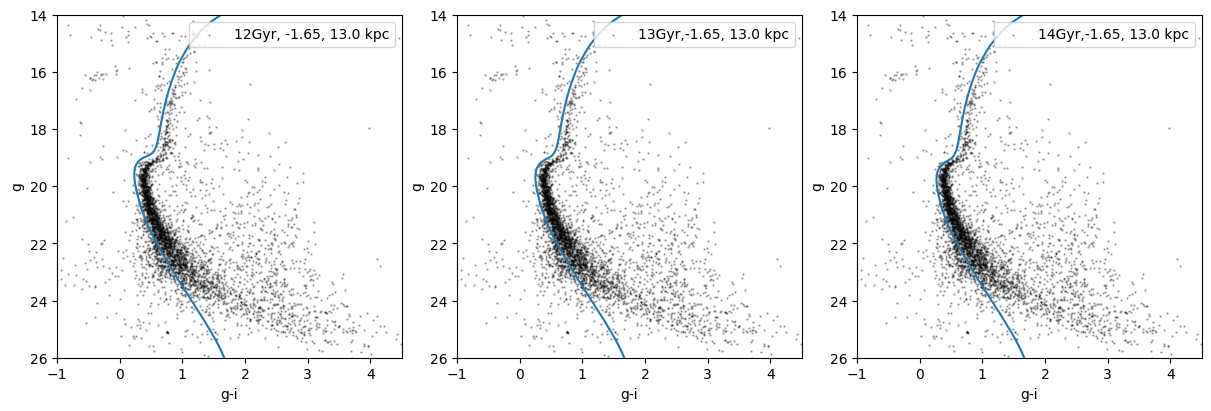

In [147]:
fig,ax=plt.subplots(1,3,constrained_layout=True,figsize=(12,4))

ax[0].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"12Gyr, -1.65, {distance}")
ax[0].plot(color_g_i1, mag_g1)
ax[0].invert_yaxis() 
ax[0].set_xlim([-1.0, 4.5])
ax[0].set_ylim([26.0, 14.0])
ax[0].set_xlabel("g-i")
ax[0].set_ylabel("g")
ax[0].legend()

ax[1].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"13Gyr,-1.65, {distance}")
ax[1].plot(color_g_i11, mag_g11)
ax[1].invert_yaxis() 
ax[1].set_xlim([-1.0, 4.5])
ax[1].set_ylim([26.0, 14.0])
ax[1].set_xlabel("g-i")
ax[1].set_ylabel("g")
ax[1].legend()

ax[2].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr,-1.65, {distance}")
ax[2].plot(color_g_i12, mag_g12)
ax[2].invert_yaxis() 
ax[2].set_xlim([-1.0, 4.5])
ax[2].set_ylim([26.0, 14.0])
ax[2].set_xlabel("g-i")
ax[2].set_ylabel("g")
ax[2].legend()

plt.savefig("age vary")

From the above fits, we see the best isochrone that traces the data is the one with age 14Gyrs. So now we move to the next step.

STEP 2: Fix the age to 14Gyr and vary the metallicity [Fe/H], again keeping the distance estimated at 13 kpc.

In [148]:
# importing isochrones of age 14 Gyr and varying metallicity

filename121=r"D:\ug disso\MIST_iso_67b02ebedfca1.iso.cmd"   # age 14gyr, mett=-1.55
filename122=r"D:\ug disso\MIST_iso_67b048ba8ec86.iso.cmd"   # age 14gyr, mett=-1.75
filename123=r"D:\ug disso\MIST_iso_67b04f6d68d84.iso.cmd"   # age 14gyr, mett=-1.60

iso121 = read_mist_models.ISOCMD(filename121)
iso122 = read_mist_models.ISOCMD(filename122)
iso122 = read_mist_models.ISOCMD(filename123)

Reading in: D:\ug disso\MIST_iso_67b02ebedfca1.iso.cmd
Reading in: D:\ug disso\MIST_iso_67b048ba8ec86.iso.cmd
Reading in: D:\ug disso\MIST_iso_67b04f6d68d84.iso.cmd


In [149]:
iso_array121 = iso121.isocmds[0]
iso_array122 = iso122.isocmds[0]
iso_array123 = iso122.isocmds[0]

iso_array121['phase']
iso_array122['phase']
iso_array123['phase']

array([0., 0., 0., ..., 6., 6., 6.], shape=(1457,))

In [150]:
phase_mask121 = (iso_array121['phase'] >= 0) & (iso_array121['phase'] < 3)
main_sequence121 = iso_array121[phase_mask121]
phase_mask121.sum()

phase_mask122 = (iso_array122['phase'] >= 0) & (iso_array122['phase'] < 3)
main_sequence122 = iso_array122[phase_mask122]
phase_mask122.sum()

phase_mask123 = (iso_array123['phase'] >= 0) & (iso_array123['phase'] < 3)
main_sequence123 = iso_array123[phase_mask123]
phase_mask123.sum()

np.int64(351)

In [155]:
mag_g121 = main_sequence121['SDSS_g'] + distmod 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 

mag_g122 = main_sequence122['SDSS_g'] + distmod 
color_g_i122 = main_sequence122['SDSS_g'] - main_sequence122['SDSS_i'] 

mag_g123 = main_sequence123['SDSS_g'] + distmod 
color_g_i123 = main_sequence123['SDSS_g'] - main_sequence123['SDSS_i'] 

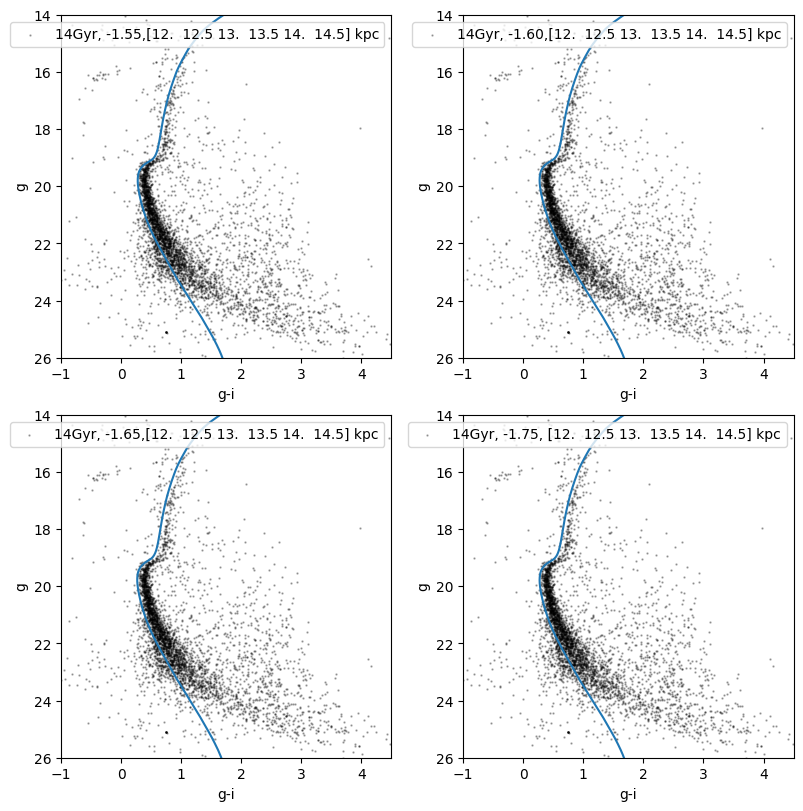

In [177]:
fig,ax=plt.subplots(2,2,constrained_layout=True,figsize=(8,8))


ax[0,0].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance}")
ax[0,0].plot(color_g_i121, mag_g121)
ax[0,0].invert_yaxis() 
ax[0,0].set_xlim([-1.0, 4.5])
ax[0,0].set_ylim([26.0, 14.0])
ax[0,0].set_xlabel("g-i")
ax[0,0].set_ylabel("g")
ax[0,0].legend()

ax[0,1].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.60,{distance}")
ax[0,1].plot(color_g_i123, mag_g123)
ax[0,1].invert_yaxis() 
ax[0,1].set_xlim([-1.0, 4.5])
ax[0,1].set_ylim([26.0, 14.0])
ax[0,1].set_xlabel("g-i")
ax[0,1].set_ylabel("g")
ax[0,1].legend()

ax[1,0].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.65,{distance}")
ax[1,0].plot(color_g_i12, mag_g12)
ax[1,0].invert_yaxis() 
ax[1,0].set_xlim([-1.0, 4.5])
ax[1,0].set_ylim([26.0, 14.0])
ax[1,0].set_xlabel("g-i")
ax[1,0].set_ylabel("g")
ax[1,0].legend()

ax[1,1].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.75, {distance}")
ax[1,1].plot(color_g_i122, mag_g122)
ax[1,1].invert_yaxis() 
ax[1,1].set_xlim([-1.0, 4.5])
ax[1,1].set_ylim([26.0, 14.0])
ax[1,1].set_xlabel("g-i")
ax[1,1].set_ylabel("g")
ax[1,1].legend()

plt.savefig("14Gyr, meta vary")

Now age=14Gyr and metallicity=-1.55 is fixed, since that fits the data best. 

STEP 3: To vary the distance

In [156]:
dis=np.arange(12,15,0.5)
distance = dis * u.kpc
distmodzz = coord.Distance(distance).distmod.value

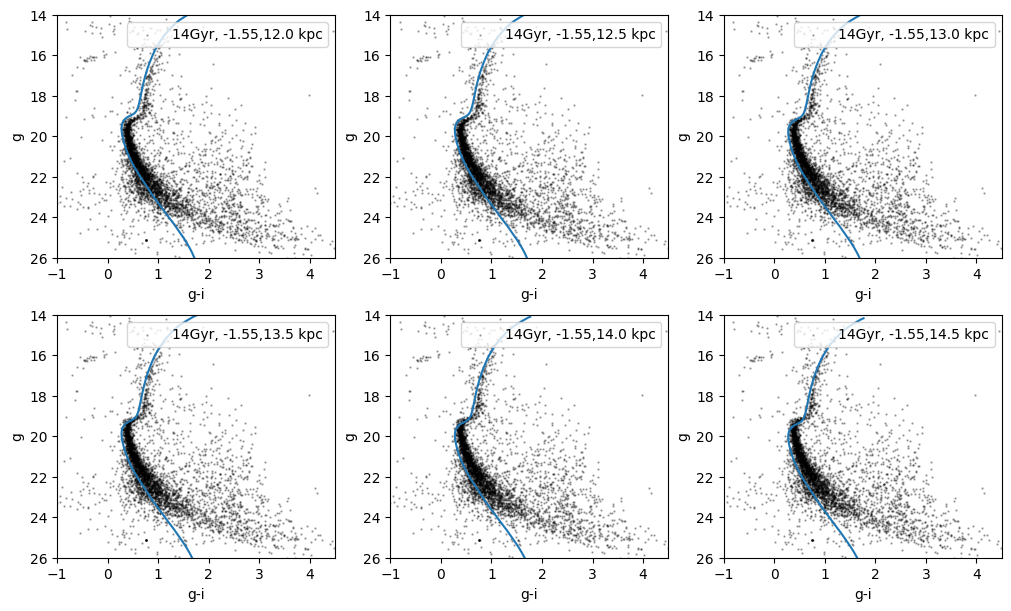

In [158]:
fig,ax=plt.subplots(2,3,constrained_layout=True,figsize=(10,6))

mag_g121_0 = main_sequence121['SDSS_g'] + distmodzz[0] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[0,0].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[0]}")
ax[0,0].plot(color_g_i121, mag_g121_0)
ax[0,0].invert_yaxis() 
ax[0,0].set_xlim([-1.0, 4.5])
ax[0,0].set_ylim([26.0, 14.0])
ax[0,0].set_xlabel("g-i")
ax[0,0].set_ylabel("g")
ax[0,0].legend()

mag_g121_1 = main_sequence121['SDSS_g'] + distmodzz[1] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[0,1].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[1]}")
ax[0,1].plot(color_g_i121, mag_g121_1)
ax[0,1].invert_yaxis() 
ax[0,1].set_xlim([-1.0, 4.5])
ax[0,1].set_ylim([26.0, 14.0])
ax[0,1].set_xlabel("g-i")
ax[0,1].set_ylabel("g")
ax[0,1].legend()

mag_g121_2 = main_sequence121['SDSS_g'] + distmodzz[2] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[0,2].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[2]}")
ax[0,2].plot(color_g_i121, mag_g121_2)
ax[0,2].invert_yaxis() 
ax[0,2].set_xlim([-1.0, 4.5])
ax[0,2].set_ylim([26.0, 14.0])
ax[0,2].set_xlabel("g-i")
ax[0,2].set_ylabel("g")
ax[0,2].legend()

mag_g121_3 = main_sequence121['SDSS_g'] + distmodzz[3] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[1,0].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[3]}")
ax[1,0].plot(color_g_i121, mag_g121_3)
ax[1,0].invert_yaxis() 
ax[1,0].set_xlim([-1.0, 4.5])
ax[1,0].set_ylim([26.0, 14.0])
ax[1,0].set_xlabel("g-i")
ax[1,0].set_ylabel("g")
ax[1,0].legend()

mag_g121_4 = main_sequence121['SDSS_g'] + distmodzz[4] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[1,1].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[4]}")
ax[1,1].plot(color_g_i121, mag_g121_4)
ax[1,1].invert_yaxis() 
ax[1,1].set_xlim([-1.0, 4.5])
ax[1,1].set_ylim([26.0, 14.0])
ax[1,1].set_xlabel("g-i")
ax[1,1].set_ylabel("g")
ax[1,1].legend()

mag_g121_5 = main_sequence121['SDSS_g'] + distmodzz[5] 
color_g_i121 = main_sequence121['SDSS_g'] - main_sequence121['SDSS_i'] 
ax[1,2].scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black', label=f"14Gyr, -1.55,{distance[5]}")
ax[1,2].plot(color_g_i121, mag_g121_5)
ax[1,2].invert_yaxis() 
ax[1,2].set_xlim([-1.0, 4.5])
ax[1,2].set_ylim([26.0, 14.0])
ax[1,2].set_xlabel("g-i")
ax[1,2].set_ylabel("g")
ax[1,2].legend()

plt.savefig("Distance vary")

The bottom left isochrone has the best fit. This corresponds to distance= 13.5 kpc

Lets try to put this isochrone and this data in a proper fitted frame.

In [159]:
iso_df = pd.DataFrame()
iso_df['mag_g'] = mag_g121_3
iso_df['color_g_i'] = color_g_i121

iso_df.head()

,mag_g,color_g_i
0,29.798068,2.441926
1,29.691220,2.409074
2,29.547518,2.365745
3,29.408427,2.324497
4,29.269490,2.284088


In [160]:
g = iso_df['mag_g']

g_mask = (g > 18.0) & (g <24.0)
g_mask.sum()

iso_masked = iso_df[g_mask]

In [161]:
g = iso_masked['mag_g']
left_color = iso_masked['color_g_i'] - 0.2
right_color = iso_masked['color_g_i'] + 0.3

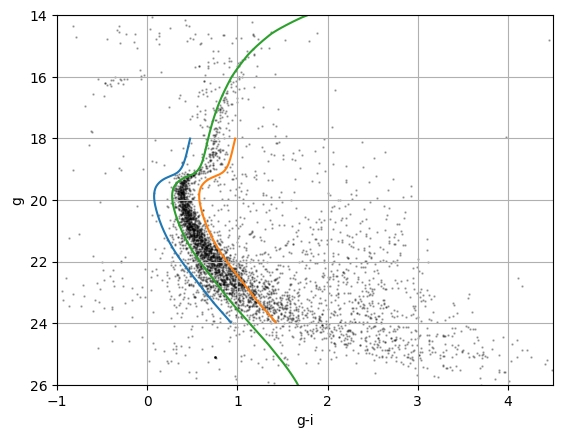

In [162]:
plt.scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='black')
plt.gca().invert_yaxis() 
plt.xlim(-1.0, 4.5)
plt.ylim(26.0, 14.0)
plt.xlabel("g-i")
plt.ylabel("g")
plt.grid()
plt.plot(left_color, g, label='left color')
plt.plot(right_color, g, label='right color')
plt.plot(color_g_i121, mag_g121_3)

In [163]:
def front_to_back(first, second):
    """Join two arrays front to back."""
    return np.append(first, second[::-1])

In [164]:
color_loop = front_to_back(left_color, right_color)
mag_loop = front_to_back(g, g)
print(mag_loop.shape)
print(color_loop.shape)

(328,)
(328,)


In [165]:
loop_df = pd.DataFrame()
loop_df['color_loop'] = color_loop
loop_df['mag_loop'] = mag_loop

from matplotlib.patches import Polygon
polygon = Polygon(loop_df)

points = pd.DataFrame()
points['color'] = df1["g"]-df1["i"]
points['mag'] = df1["g"]

inside = polygon.contains_points(points)
winner_df = df1[inside]

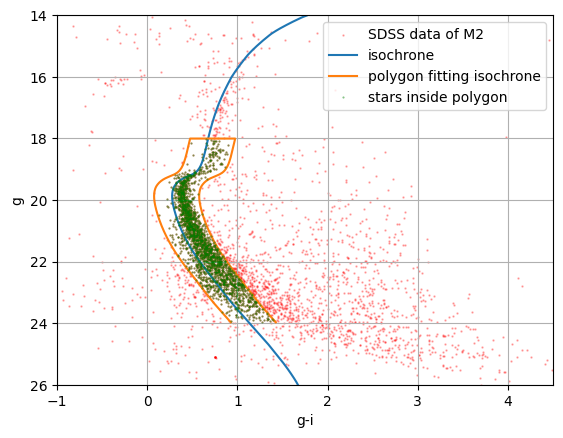

In [171]:
plt.scatter(df1["g"]-df1["i"], df1["g"], s=0.5, alpha=0.3, color='red',label="SDSS data of M2")
plt.gca().invert_yaxis() 
plt.xlim(-1.0, 4.5)
plt.ylim(26.0, 14.0)
plt.xlabel("g-i")
plt.ylabel("g")
plt.grid()
plt.plot(color_g_i121, mag_g121_3, label="isochrone")
plt.plot(color_loop, mag_loop, label="polygon fitting isochrone")

x = winner_df['g'] - winner_df['i']
y = winner_df['g']
plt.plot(x, y, 'go', markersize=0.5, alpha=0.5, label="stars inside polygon")
plt.legend()

plt.savefig("final fit")